In [83]:
import numpy as np
import scanpy as sc
import pandas as pd
import os
from matplotlib import pyplot as plt
from umap import UMAP
import seaborn as sns
import sys; sys.path += ['./../../']
from CardamomOT import NetworkModel as CardamomNetworkModel
from CardamomOT import train_classifier, predict_cell_types
from harissa import NetworkModel as HarissaNetworkModel

In [84]:
def run_inference(rna_data, prot_data, time, deg_rates, random_state=42, min_dist=0.7, n_neighbors=15):
    # ---- CardamomOT fit ----
    valid_mask = time > 0
    x = rna_data[1:, 1:].copy()
    x[:, 0] = time
    G = x.shape[1]
    model = CardamomNetworkModel(G - 1)
    model.d = deg_rates
    model.fit(x)
    # model.adapt_to_unitary()

    inferred_prot = model.prot
    reference_prot = prot_data[valid_mask, 1:]
    inferred_prot = inferred_prot[valid_mask, 1:]
    reference_prot_scaled = reference_prot
    inferred_prot_scaled = inferred_prot
    combined = np.vstack([reference_prot_scaled, inferred_prot_scaled])
    umap_model = UMAP(n_components=2, random_state=random_state, min_dist=min_dist, n_neighbors=n_neighbors)
    combined_umap = umap_model.fit_transform(combined)

    n_ref = len(reference_prot_scaled)
    reference_umap = combined_umap[:n_ref]
    inferred_umap = combined_umap[n_ref:]

    return reference_umap, inferred_umap, time[valid_mask]

# FN4

In [85]:
np.random.seed(0)

# Number of cells
C = 1000
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 4

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0, 1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 1
model_harissa.d[1] = 0.2
model_harissa.d /= 5

model_harissa.basal[1:] = -5
model_harissa.inter[0,1] = 10
model_harissa.inter[1,2] = 10
model_harissa.inter[1,3] = 10
model_harissa.inter[3,4] = 10
model_harissa.inter[4,1] = -10
model_harissa.inter[2,2] = 10
model_harissa.inter[3,3] = 10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj_FN4 = np.ones((C, G+1), dtype='float32')
prot_traj_FN4[:, 0] = (time > 0).astype('float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj_FN4[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj_FN4 = data[1:, 1:].copy()

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


In [86]:
reference_umap_FN4, inferred_umap_FN4, time = run_inference(data, prot_traj_FN4, time, model_harissa.d.copy())

Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Gene 1-1 calibrated... [0.112 1.566] 0.017219063188873417
Gene 2-2 calibrated... [0.018 1.753] 0.018251007132501253
Gene 3-3 calibrated... [0.014 1.78 ] 0.01867235343157196
Gene 4-4 calibrated... [0.012 1.336] 0.018042820758596798
Mean proba =  0.970251296586103 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 5
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.68194, 0.22041 | alpha mean: 0.0100
number of non reached cells 337
2 0 | Errors (before, after): 0.19852, 0.19090 | alpha mean: 0.0388
number of non reached cells 336
3 0 | Errors (before, after): 0.18525, 0.18257 | alpha mean: 0.0523
number of non reached cells 331
4 0 | Errors (before, after): 0.16564, 0.16241 | alpha mean: 0.0580
number of non reached cells 320
5 0 | Errors (before, after): 0.15257, 0

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# CN5

In [87]:
np.random.seed(0)

# Number of cells
C = 1000
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 5

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.5
model_harissa.d[1] = 0.1

model_harissa.basal[1:] = [-5, 4, 4, -5, -5]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = -10
model_harissa.inter[2, 3] = -10
model_harissa.inter[3, 4] = 10
model_harissa.inter[4, 5] = 10
model_harissa.inter[5, 1] = -10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj_CN5 = np.ones((C, G+1), dtype='float32')
prot_traj_CN5[:, 0] = (time > 0).astype('float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj_CN5[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj_CN5 = data[1:,1:].copy()

reference_umap_CN5, inferred_umap_CN5, time = run_inference(data, prot_traj_CN5, time, model_harissa.d.copy())

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Gene 1-1 calibrated... [0.13  1.827] 0.019451378776009037
Gene 2-2 calibrated... [0.12  1.504] 0.018638369742152612
Gene 3-3 calibrated... [0.244 1.801] 0.019696314689283453
Gene 4-4 calibrated... [0.096 1.338] 0.01619840832889756
Gene 5-5 calibrated... [0.068 1.819] 0.02033995099483852
Mean proba =  0.9073021354982699 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 6
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.67398, 0.39841 | alpha mean: 0.0100
number of non reached cells 350
2 0 | Errors (before, after): 0.39328, 0.38921 | alpha mean: 0.1766
number of non reached cells 331
3 0 | Errors (before, after): 0.36826, 0.34946 | alpha mean: 0.3051
number of non reached cells 328
4 0 | Errors (before

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# BN8

In [88]:
np.random.seed(0)

# Number of cells
C = 1000

# Time points
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96] 
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 8

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.25
model_harissa.d[1] = 0.05

model_harissa.basal[1:] = [-4, -4, -4, -4, -4, -4, -4, -4]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = 10
model_harissa.inter[1, 3] = 10
model_harissa.inter[3, 2] = -10
model_harissa.inter[2, 3] = -10
model_harissa.inter[2, 2] = 5
model_harissa.inter[3, 3] = 5
model_harissa.inter[2, 4] = 10
model_harissa.inter[3, 5] = 10
model_harissa.inter[2, 5] = -10
model_harissa.inter[3, 4] = -10
model_harissa.inter[4, 7] = -10
model_harissa.inter[5, 6] = -10
model_harissa.inter[4, 6] = 10
model_harissa.inter[5, 7] = 10
model_harissa.inter[7, 8] = 10
model_harissa.inter[6, 8] = -10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj_BN8 = np.ones((C, G+1), dtype='float32')
prot_traj_BN8[:, 0] = (time > 0).astype('float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj_BN8[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj_BN8 = data[1:,1:].copy()

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


In [89]:
reference_umap_BN8, inferred_umap_BN8, time = run_inference(data, prot_traj_BN8, time, model_harissa.d.copy())

Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Calibrating gene 6
Calibrating gene 7
Calibrating gene 8
Gene 1-1 calibrated... [0.009 1.775] 0.017535021234647816
Gene 2-2 calibrated... [0.076 1.74 ] 0.018075420185711386
Gene 3-3 calibrated... [0.09  1.725] 0.01894421498369963
Gene 4-4 calibrated... [0.035 1.726] 0.018090608408416982
Gene 5-5 calibrated... [0.023 1.729] 0.021365358796889392
Gene 6-6 calibrated... [0.016 0.915] 0.014225639701644843
Gene 7-7 calibrated... [0.022 1.112] 0.01489111360822391
Gene 8-8 calibrated... [0.006 0.476] 0.01
Mean proba =  0.9557609930622568 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 9
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.69732, 0.34949 | alpha mean: 0.0100
number of non reached cells 349
2 0 | Errors (before, after): 0.30400, 0.29310 |

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# FN8

In [90]:
np.random.seed(0)

# Number of cells
C = 1000
# Time points
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96] # np.linspace(0, 25, 10, dtype='int')
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 8

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.4
model_harissa.d[1] = 0.08

model_harissa.basal[1:] = [-5, -5, -5, -5, -5, -5, -5, -5]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = 10
model_harissa.inter[2, 3] = 10
model_harissa.inter[3, 4] = 10
model_harissa.inter[3, 5] = 10
model_harissa.inter[3, 6] = 10
model_harissa.inter[4, 1] = -10
model_harissa.inter[5, 1] = -10
model_harissa.inter[6, 1] = -10
model_harissa.inter[4, 4] = 10
model_harissa.inter[5, 5] = 10
model_harissa.inter[6, 6] = 10
model_harissa.inter[4, 8] = -10
model_harissa.inter[4, 7] = -10
model_harissa.inter[6, 7] = 10
model_harissa.inter[7, 6] = 10
model_harissa.inter[8, 8] = 10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj_FN8 = np.ones((C, G+1), dtype='float32')
prot_traj_FN8[:, 0] = (time > 0).astype('float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj_FN8[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj_FN8 = data[1:,1:].copy()

reference_umap_FN8, inferred_umap_FN8, time = run_inference(data, prot_traj_FN8, time, model_harissa.d.copy())

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Calibrating gene 6
Calibrating gene 7
Calibrating gene 8
Gene 1-1 calibrated... [0.046 1.703] 0.018136346296777083
Gene 2-2 calibrated... [0.058 1.38 ] 0.01742301385364315
Gene 3-3 calibrated... [0.053 1.425] 0.018915772139588224
Gene 4-4 calibrated... [0.02  1.652] 0.016347718542540007
Gene 5-5 calibrated... [0.025 2.029] 0.020906231240546632
Gene 6-6 calibrated... [0.026 2.003] 0.021485709384309267
Gene 7-7 calibrated... [0.008 0.496] 0.012114933473628318
Gene 8-8 calibrated... [0.007 0.43 ] 0.029972216559267923
Mean proba =  0.9598835343749151 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 9
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.69791, 0.25212 | alpha mean: 0.0100
number of non reache

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Plot

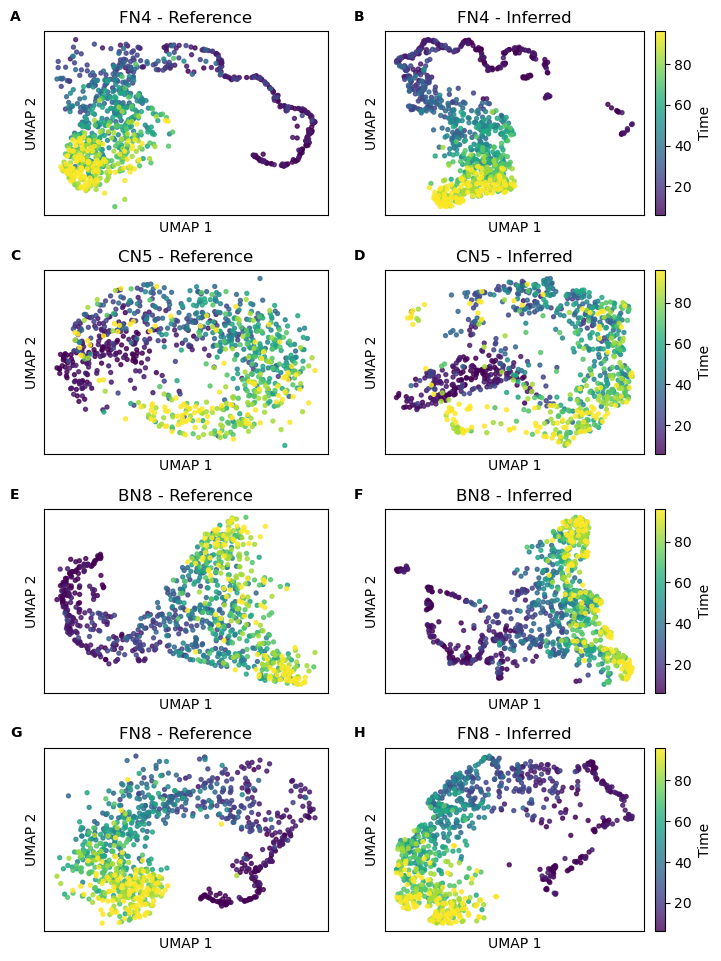

In [91]:
datasets = [
    ("FN4", reference_umap_FN4, inferred_umap_FN4, time),
    ("CN5", reference_umap_CN5, inferred_umap_CN5, time),
    ("BN8", reference_umap_BN8, inferred_umap_BN8, time),
    ("FN8", reference_umap_FN8, inferred_umap_FN8, time),
]
fig, axes = plt.subplots(4, 2, figsize=(8.27, 11.69))

valid_times = [times for _, _, _, times in datasets if len(times) > 0]
vmin = min(np.min(t) for t in valid_times)
vmax = max(np.max(t) for t in valid_times)

def style_axis(ax, title):
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_xticks([])
    ax.set_yticks([])

for row, (dataset_name, reference_umap, inferred_umap, times) in enumerate(datasets):
    ref_plot = reference_umap
    inf_plot = inferred_umap
    times_plot = times

    ax_ref = axes[row, 0]
    ax_ref.scatter(
        ref_plot[:, 0],
        ref_plot[:, 1],
        c=times_plot,
        s=8,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        alpha=0.8,
    )
    style_axis(ax_ref, f"{dataset_name} - Reference")

    ax_inf = axes[row, 1]
    sc_inf = ax_inf.scatter(
        inf_plot[:, 0],
        inf_plot[:, 1],
        c=times_plot,
        s=8,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        alpha=0.8,
    )
    style_axis(ax_inf, f"{dataset_name} - Inferred")
    cbar_inf = fig.colorbar(sc_inf, ax=ax_inf, fraction=0.046, pad=0.04)
    cbar_inf.set_label("Time")

for ax, label in zip(axes.flatten(), "ABCDEFGH"):
    ax.text(
        -0.12,
        1.04,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.subplots_adjust(hspace=0.3, wspace=0.2, right=0.88)
plt.savefig("figureS6.pdf", dpi=600, bbox_inches="tight", pad_inches=0.05)
plt.show()